In [1]:
import pandas as pd
import os 
import random
import subprocess

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
biovar= 'bio1'

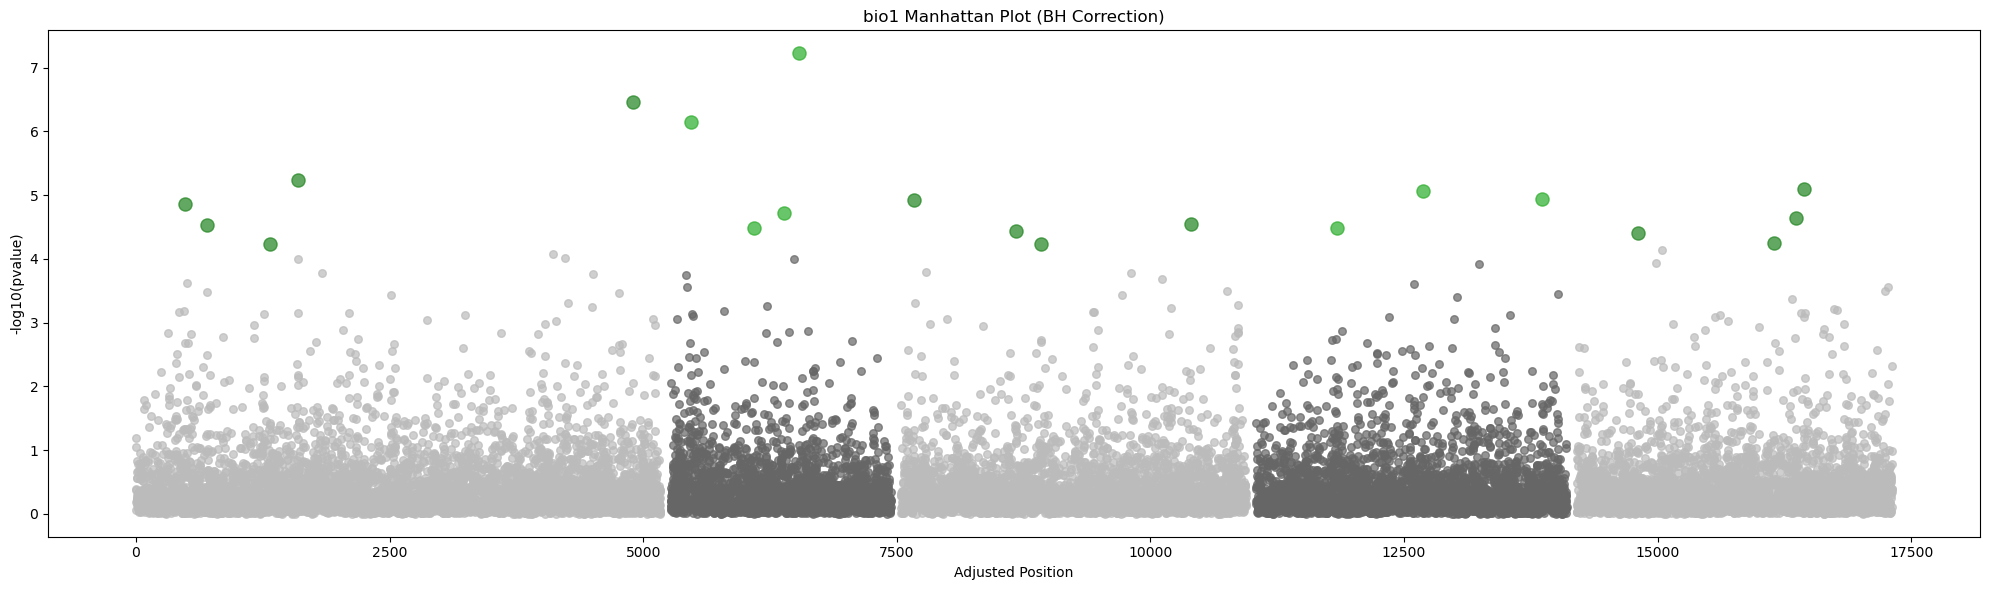

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

# Load the data
wza_lfmm = pd.read_csv('../wza/wza_results_lfmm_bio1_poly7.csv')

# Extract chromosome and position from the gene column
wza_lfmm['chrom'] = wza_lfmm['gene'].str.split('_').str[0].astype(int)
wza_lfmm['pos'] = wza_lfmm['gene'].str.split('_').str[1].astype(int)

# Create chrom_pos in wza_lfmm by combining 'chrom' and 'pos'
wza_lfmm['chrom_pos'] = wza_lfmm['chrom'].astype(str) + '_' + wza_lfmm['pos'].astype(str)

# Copy the relevant columns for plotting
df = wza_lfmm[['Z_pVal', 'pos', 'chrom', 'chrom_pos']].copy()

# Parse chromosome number and position
df['chromosome'] = df['chrom']
df['position'] = df['pos']
df['-log10(pvalue)'] = -np.log10(df['Z_pVal'])

# Apply Benjamini-Hochberg correction
df['BH_corrected_pval'] = multipletests(df['Z_pVal'], method='fdr_bh')[1]
threshold = -np.log10(0.05)  # This is the threshold for significance (adjusted for BH)

# Define grey tones for each chromosome (alternating dark and light greys)
greyscale_colors = ['#666666', '#BBBBBB', '#666666', '#BBBBBB', '#666666', '#BBBBBB']

# Define green tones for significant points (alternating dark and light greens)
green_colors = ['#2aad2a', '#208420']

# Calculate chromosome offsets to prevent overlap
chromosome_offsets = {}
offset = 0
for chrom in sorted(df['chromosome'].unique()):
    chromosome_offsets[chrom] = offset
    max_position = df[df['chromosome'] == chrom]['position'].max()
    offset += max_position + 100  # Add buffer to prevent overlap

# Apply offsets to the position
df['adjusted_position'] = df.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)

# Create the Manhattan plot
plt.figure(figsize=(20, 6))

# Plot each chromosome separately
for chrom in sorted(df['chromosome'].unique()):
    subset = df[df['chromosome'] == chrom]
    
    # Separate significant points (above threshold) and non-significant points
    significant = subset[subset['BH_corrected_pval'] < 0.05]
    non_significant = subset[subset['BH_corrected_pval'] >= 0.05]
    
    # Plot non-significant points in greyscale
    plt.scatter(
        non_significant['adjusted_position'],
        non_significant['-log10(pvalue)'],
        alpha=0.7, 
        c=greyscale_colors[chrom % len(greyscale_colors)],  # Apply greyscale color shades
        s=30,  # Default size for non-significant points
        label=f'Chr {chrom}'
    )
    
    # Plot significant points in alternating shades of green with bigger size
    plt.scatter(
        significant['adjusted_position'],
        significant['-log10(pvalue)'],
        alpha=0.7, 
        c=green_colors[chrom % len(green_colors)],  # Alternate green color shades
        s=90,  # Bigger size for significant points
        label=f'Significant Chr {chrom}'
    )

# Aesthetics
plt.xlabel('Adjusted Position')
plt.ylabel('-log10(pvalue)')
plt.title(f'{biovar} Manhattan Plot (BH Correction)')

# Remove grid lines
plt.grid(False)

# Tight layout for better spacing
plt.tight_layout()
# plt.savefig("manhattan_plot_lfmm_zwa_bh.svg", format="svg")
# Show the plot
plt.show()


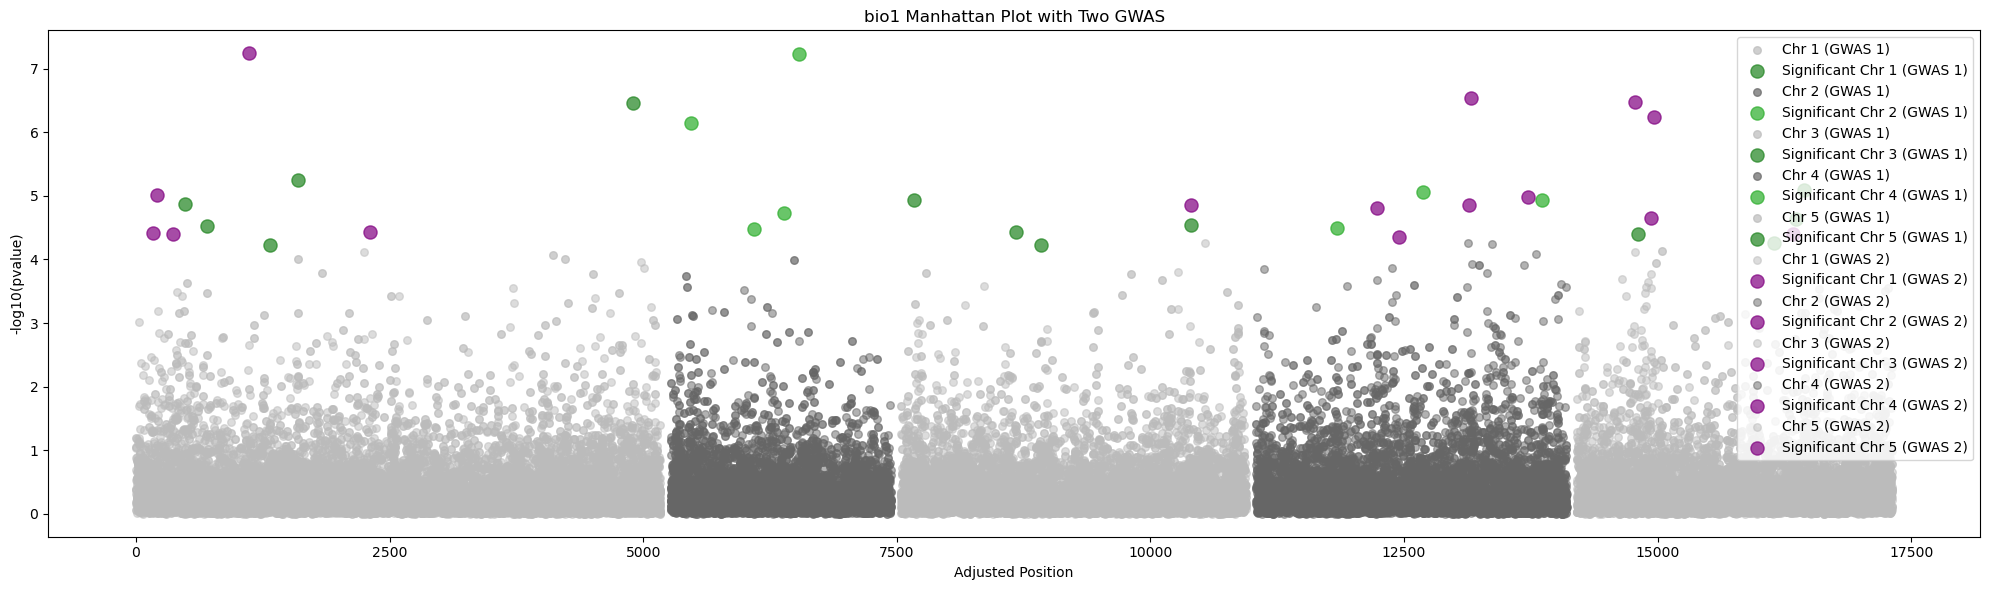

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

# Load the first GWAS data
wza_lfmm = pd.read_csv('../wza/wza_results_lfmm_bio1_poly7.csv')

# Extract chromosome and position from the gene column
wza_lfmm['chrom'] = wza_lfmm['gene'].str.split('_').str[0].astype(int)
wza_lfmm['pos'] = wza_lfmm['gene'].str.split('_').str[1].astype(int)

# Create chrom_pos in wza_lfmm by combining 'chrom' and 'pos'
wza_lfmm['chrom_pos'] = wza_lfmm['chrom'].astype(str) + '_' + wza_lfmm['pos'].astype(str)

# Copy the relevant columns for plotting
df1 = wza_lfmm[['Z_pVal', 'pos', 'chrom', 'chrom_pos']].copy()

# Parse chromosome number and position
df1['chromosome'] = df1['chrom']
df1['position'] = df1['pos']
df1['-log10(pvalue)'] = -np.log10(df1['Z_pVal'])

# Apply Benjamini-Hochberg correction
df1['BH_corrected_pval'] = multipletests(df1['Z_pVal'], method='fdr_bh')[1]
threshold = -np.log10(0.05)  # This is the threshold for significance (adjusted for BH)

# Load the second GWAS data
binomial_reg = pd.read_csv('../wza/wza_binomial_regression_bio1_poly7.csv')

# Extract chromosome and position from the gene column
binomial_reg['chrom'] = binomial_reg['gene'].str.split('_').str[0].astype(int)
binomial_reg['pos'] = binomial_reg['gene'].str.split('_').str[1].astype(int)

# Create chrom_pos in binomial_reg by combining 'chrom' and 'pos'
binomial_reg['chrom_pos'] = binomial_reg['chrom'].astype(str) + '_' + binomial_reg['pos'].astype(str)

# Copy the relevant columns for plotting
df2 = binomial_reg[['Z_pVal', 'pos', 'chrom', 'chrom_pos']].copy()

# Parse chromosome number and position
df2['chromosome'] = df2['chrom']
df2['position'] = df2['pos']
df2['-log10(pvalue)'] = -np.log10(df2['Z_pVal'])

# Apply Benjamini-Hochberg correction
df2['BH_corrected_pval'] = multipletests(df2['Z_pVal'], method='fdr_bh')[1]

# Calculate chromosome offsets to prevent overlap for both datasets
chromosome_offsets = {}
offset = 0
for chrom in sorted(pd.concat([df1['chromosome'], df2['chromosome']]).unique()):
    chromosome_offsets[chrom] = offset
    max_position = max(df1[df1['chromosome'] == chrom]['position'].max(), 
                       df2[df2['chromosome'] == chrom]['position'].max())
    offset += max_position + 100  # Add buffer to prevent overlap

# Apply offsets to the position for both datasets
df1['adjusted_position'] = df1.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)
df2['adjusted_position'] = df2.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)

# Create the Manhattan plot
plt.figure(figsize=(20, 6))

# Plot the first dataset
for chrom in sorted(df1['chromosome'].unique()):
    subset = df1[df1['chromosome'] == chrom]
    
    # Separate significant points (above threshold) and non-significant points
    significant = subset[subset['BH_corrected_pval'] < 0.05]
    non_significant = subset[subset['BH_corrected_pval'] >= 0.05]
    
    # Plot non-significant points in greyscale
    plt.scatter(
        non_significant['adjusted_position'],
        non_significant['-log10(pvalue)'],
        alpha=0.7, 
        c=greyscale_colors[chrom % len(greyscale_colors)],  # Apply greyscale color shades
        s=30,  # Default size for non-significant points
        label=f'Chr {chrom} (GWAS 1)'
    )
    
    # Plot significant points in alternating shades of green with bigger size
    plt.scatter(
        significant['adjusted_position'],
        significant['-log10(pvalue)'],
        alpha=0.7, 
        c=green_colors[chrom % len(green_colors)],  # Alternate green color shades
        s=90,  # Bigger size for significant points
        label=f'Significant Chr {chrom} (GWAS 1)'
    )

# Plot the second dataset
for chrom in sorted(df2['chromosome'].unique()):
    subset = df2[df2['chromosome'] == chrom]
    
    # Separate significant points (above threshold) and non-significant points
    significant = subset[subset['BH_corrected_pval'] < 0.05]
    non_significant = subset[subset['BH_corrected_pval'] >= 0.05]
    
    # Plot non-significant points in greyscale
    plt.scatter(
        non_significant['adjusted_position'],
        non_significant['-log10(pvalue)'],
        alpha=0.5, 
        c=greyscale_colors[chrom % len(greyscale_colors)],  # Apply greyscale color shades
        s=30,  # Default size for non-significant points
        label=f'Chr {chrom} (GWAS 2)'
    )
    
    # Plot significant points in purple with bigger size
    plt.scatter(
        significant['adjusted_position'],
        significant['-log10(pvalue)'],
        alpha=0.7, 
        c='purple',  # Use purple for significant points
        s=90,  # Bigger size for significant points
        label=f'Significant Chr {chrom} (GWAS 2)'
    )

# Aesthetics
plt.xlabel('Adjusted Position')
plt.ylabel('-log10(pvalue)')
plt.title(f'{biovar} Manhattan Plot with Two GWAS')

# Remove grid lines
plt.grid(False)
plt.legend()
# Tight layout for better spacing
plt.tight_layout()
# plt.savefig("manhattan_plot_lfmm_zwa_combined.svg", format="svg")
# Show the plot
plt.legend()
plt.show()


In [13]:
greyscale_colors = ['#666666', '#BBBBBB', '#444444']

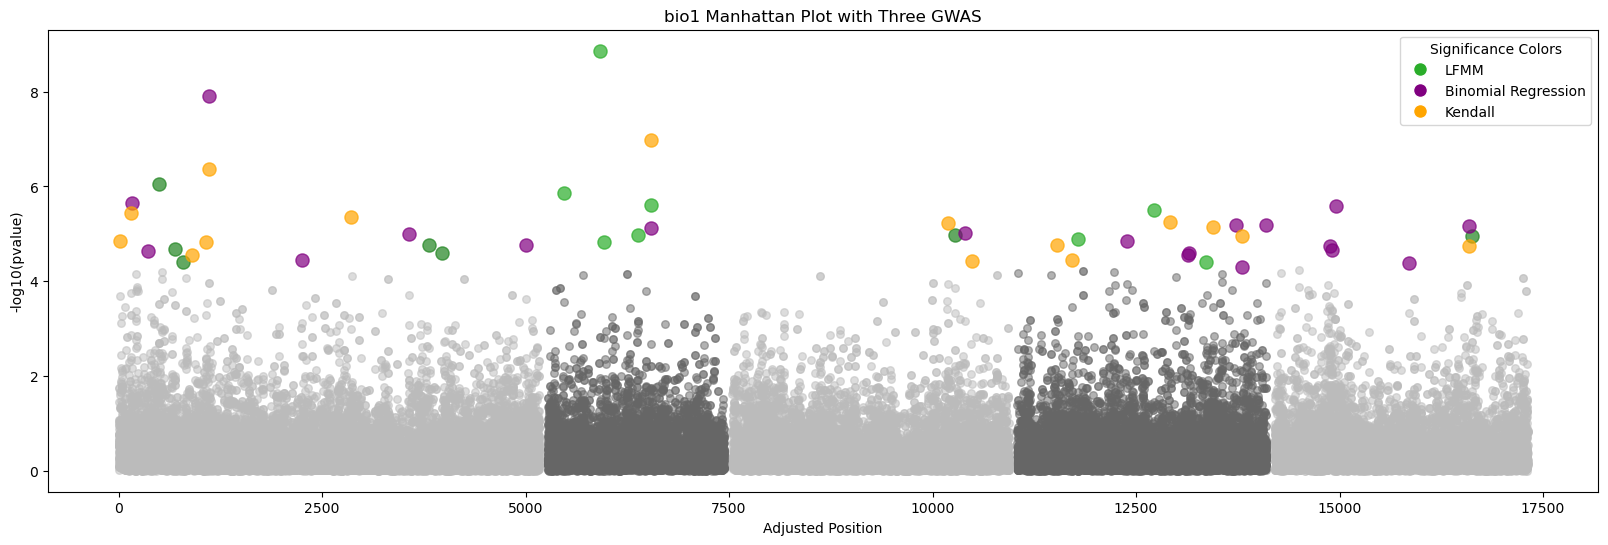

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

# Load the first GWAS data
wza_lfmm = pd.read_csv('../wza_last_gen/wza_results_lfmm_bio1_poly7.csv')

# Extract chromosome and position from the gene column
wza_lfmm['chrom'] = wza_lfmm['gene'].str.split('_').str[0].astype(int)
wza_lfmm['pos'] = wza_lfmm['gene'].str.split('_').str[1].astype(int)

# Create chrom_pos in wza_lfmm by combining 'chrom' and 'pos'
wza_lfmm['chrom_pos'] = wza_lfmm['chrom'].astype(str) + '_' + wza_lfmm['pos'].astype(str)

# Copy the relevant columns for plotting
df1 = wza_lfmm[['Z_pVal', 'pos', 'chrom', 'chrom_pos']].copy()

# Parse chromosome number and position
df1['chromosome'] = df1['chrom']
df1['position'] = df1['pos']
df1['-log10(pvalue)'] = -np.log10(df1['Z_pVal'])

# Apply Benjamini-Hochberg correction
df1['BH_corrected_pval'] = multipletests(df1['Z_pVal'], method='fdr_bh')[1]

# Load the second GWAS data
binomial_reg = pd.read_csv('../wza_last_gen/wza_binomial_regression_bio1_poly7.csv')

# Extract chromosome and position from the gene column
binomial_reg['chrom'] = binomial_reg['gene'].str.split('_').str[0].astype(int)
binomial_reg['pos'] = binomial_reg['gene'].str.split('_').str[1].astype(int)

# Create chrom_pos in binomial_reg by combining 'chrom' and 'pos'
binomial_reg['chrom_pos'] = binomial_reg['chrom'].astype(str) + '_' + binomial_reg['pos'].astype(str)

# Copy the relevant columns for plotting
df2 = binomial_reg[['Z_pVal', 'pos', 'chrom', 'chrom_pos']].copy()

# Parse chromosome number and position
df2['chromosome'] = df2['chrom']
df2['position'] = df2['pos']
df2['-log10(pvalue)'] = -np.log10(df2['Z_pVal'])

# Apply Benjamini-Hochberg correction
df2['BH_corrected_pval'] = multipletests(df2['Z_pVal'], method='fdr_bh')[1]

# Load the third GWAS data
wza_kendall = pd.read_csv('../wza_last_gen/wza_kendalltau_results_bio1_poly7.csv')

# Extract chromosome and position from the gene column
wza_kendall['chrom'] = wza_kendall['gene'].str.split('_').str[0].astype(int)
wza_kendall['pos'] = wza_kendall['gene'].str.split('_').str[1].astype(int)

# Create chrom_pos in wza_kendall by combining 'chrom' and 'pos'
wza_kendall['chrom_pos'] = wza_kendall['chrom'].astype(str) + '_' + wza_kendall['pos'].astype(str)

# Copy the relevant columns for plotting
df3 = wza_kendall[['Z_pVal', 'pos', 'chrom', 'chrom_pos']].copy()

# Parse chromosome number and position
df3['chromosome'] = df3['chrom']
df3['position'] = df3['pos']
df3['-log10(pvalue)'] = -np.log10(df3['Z_pVal'])

# Apply Benjamini-Hochberg correction
df3['BH_corrected_pval'] = multipletests(df3['Z_pVal'], method='fdr_bh')[1]

# Calculate chromosome offsets to prevent overlap for all datasets
chromosome_offsets = {}
offset = 0
for chrom in sorted(pd.concat([df1['chromosome'], df2['chromosome'], df3['chromosome']]).unique()):
    chromosome_offsets[chrom] = offset
    max_position = max(df1[df1['chromosome'] == chrom]['position'].max(), 
                       df2[df2['chromosome'] == chrom]['position'].max(),
                       df3[df3['chromosome'] == chrom]['position'].max())
    offset += max_position + 100  # Add buffer to prevent overlap

# Apply offsets to the position for all datasets
df1['adjusted_position'] = df1.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)
df2['adjusted_position'] = df2.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)
df3['adjusted_position'] = df3.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)

# Create the Manhattan plot
plt.figure(figsize=(20, 6))

# Plot the first dataset (LFMM)
for chrom in sorted(df1['chromosome'].unique()):
    subset = df1[df1['chromosome'] == chrom]
    
    # Separate significant points (above threshold) and non-significant points
    significant = subset[subset['BH_corrected_pval'] < 0.05]
    non_significant = subset[subset['BH_corrected_pval'] >= 0.05]
    
    # Plot non-significant points in greyscale
    plt.scatter(
        non_significant['adjusted_position'],
        non_significant['-log10(pvalue)'],
        alpha=0.7, 
        c=greyscale_colors[chrom % len(greyscale_colors)],  # Apply greyscale color shades
        s=30,  # Default size for non-significant points
    )
    
    # Plot significant points in alternating shades of green with bigger size
    plt.scatter(
        significant['adjusted_position'],
        significant['-log10(pvalue)'],
        alpha=0.7, 
        c=green_colors[chrom % len(green_colors)],  # Alternate green color shades
        s=90,  # Bigger size for significant points
    )

# Plot the second dataset (Binomial Regression)
for chrom in sorted(df2['chromosome'].unique()):
    subset = df2[df2['chromosome'] == chrom]
    
    # Separate significant points (above threshold) and non-significant points
    significant = subset[subset['BH_corrected_pval'] < 0.05]
    non_significant = subset[subset['BH_corrected_pval'] >= 0.05]
    
    # Plot non-significant points in greyscale
    plt.scatter(
        non_significant['adjusted_position'],
        non_significant['-log10(pvalue)'],
        alpha=0.5, 
        c=greyscale_colors[chrom % len(greyscale_colors)],  # Apply greyscale color shades
        s=30,  # Default size for non-significant points
    )
    
    # Plot significant points in purple with bigger size
    plt.scatter(
        significant['adjusted_position'],
        significant['-log10(pvalue)'],
        alpha=0.7, 
        c='purple',  # Use purple for significant points
        s=90,  # Bigger size for significant points
    )

# Plot the third dataset (Kendall)
for chrom in sorted(df3['chromosome'].unique()):
    subset = df3[df3['chromosome'] == chrom]
    
    # Separate significant points (above threshold) and non-significant points
    significant = subset[subset['BH_corrected_pval'] < 0.05]
    non_significant = subset[subset['BH_corrected_pval'] >= 0.05]
    
    # Plot non-significant points in greyscale
    plt.scatter(
        non_significant['adjusted_position'],
        non_significant['-log10(pvalue)'],
        alpha=0.5, 
        c=greyscale_colors[chrom % len(greyscale_colors)],  # Apply greyscale color shades
        s=30,  # Default size for non-significant points
    )
    
    # Plot significant points in orange with bigger size
    plt.scatter(
        significant['adjusted_position'],
        significant['-log10(pvalue)'],
        alpha=0.7, 
        c='orange',  # Use orange for significant points
        s=90,  # Bigger size for significant points
    )

# Aesthetics
plt.xlabel('Adjusted Position')
plt.ylabel('-log10(pvalue)')
plt.title(f'{biovar} Manhattan Plot with Three GWAS')

# Create a custom legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='LFMM', markerfacecolor=green_colors[0], markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Binomial Regression', markerfacecolor='purple', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Kendall', markerfacecolor='orange', markersize=10),
]

plt.legend(handles=handles, title='Significance Colors')

# Remove grid lines
plt.grid(False)

# Tight layout


In [22]:
df['chrom'].unique()

array([1, 2, 3, 4, 5])

In [23]:
pd.concat([df1['chrom'], df2['chrom'], df3['chrom']])

,chrom,chrom
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
16651,5,5
16652,5,5
16653,5,5
16654,5,5


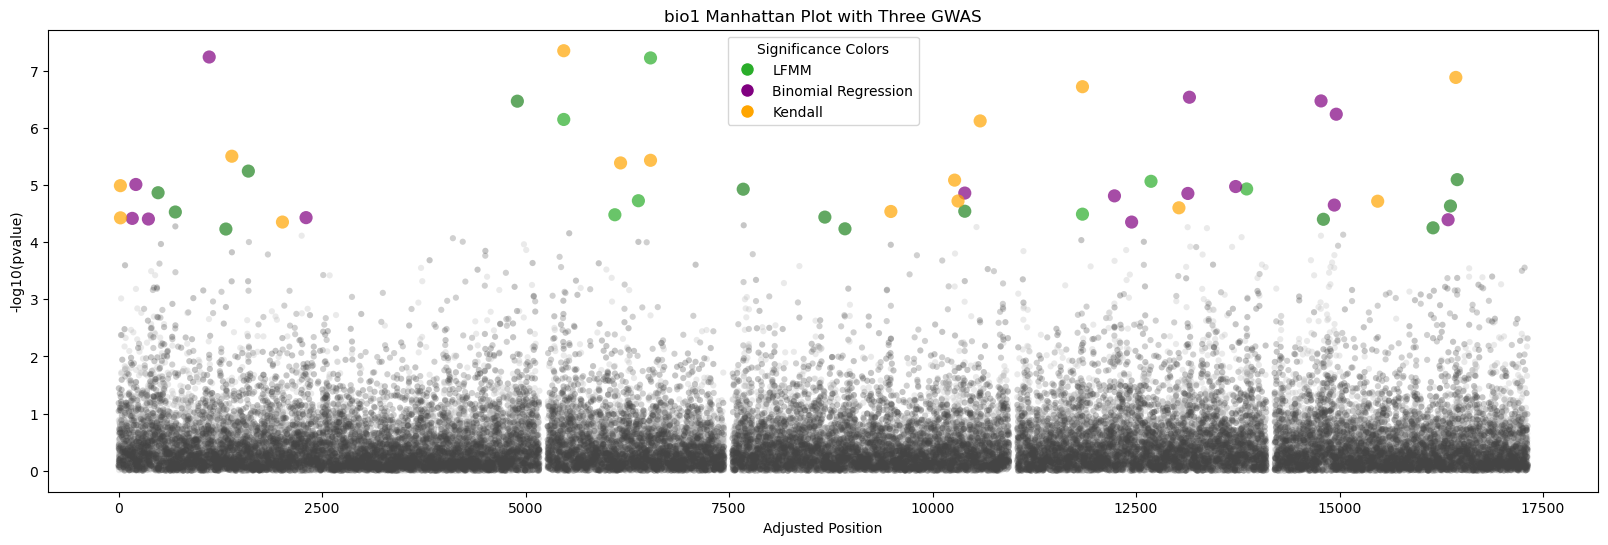

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

# Load the first GWAS data
wza_lfmm = pd.read_csv('../wza/wza_results_lfmm_bio1_poly7.csv')

# Extract chromosome and position from the gene column
wza_lfmm['chrom'] = wza_lfmm['gene'].str.split('_').str[0].astype(int)
wza_lfmm['pos'] = wza_lfmm['gene'].str.split('_').str[1].astype(int)

# Create chrom_pos in wza_lfmm by combining 'chrom' and 'pos'
wza_lfmm['chrom_pos'] = wza_lfmm['chrom'].astype(str) + '_' + wza_lfmm['pos'].astype(str)

# Copy the relevant columns for plotting
df1 = wza_lfmm[['Z_pVal', 'pos', 'chrom', 'chrom_pos']].copy()

# Parse chromosome number and position
df1['chromosome'] = df1['chrom']
df1['position'] = df1['pos']
df1['-log10(pvalue)'] = -np.log10(df1['Z_pVal'])

# Apply Benjamini-Hochberg correction
df1['BH_corrected_pval'] = multipletests(df1['Z_pVal'], method='fdr_bh')[1]

# Load the second GWAS data
binomial_reg = pd.read_csv('../wza/wza_binomial_regression_bio1_poly7.csv')

# Extract chromosome and position from the gene column
binomial_reg['chrom'] = binomial_reg['gene'].str.split('_').str[0].astype(int)
binomial_reg['pos'] = binomial_reg['gene'].str.split('_').str[1].astype(int)

# Create chrom_pos in binomial_reg by combining 'chrom' and 'pos'
binomial_reg['chrom_pos'] = binomial_reg['chrom'].astype(str) + '_' + binomial_reg['pos'].astype(str)

# Copy the relevant columns for plotting
df2 = binomial_reg[['Z_pVal', 'pos', 'chrom', 'chrom_pos']].copy()

# Parse chromosome number and position
df2['chromosome'] = df2['chrom']
df2['position'] = df2['pos']
df2['-log10(pvalue)'] = -np.log10(df2['Z_pVal'])

# Apply Benjamini-Hochberg correction
df2['BH_corrected_pval'] = multipletests(df2['Z_pVal'], method='fdr_bh')[1]

# Load the third GWAS data
wza_kendall = pd.read_csv('../wza/wza_kendalltau_results_bio1_poly7.csv')

# Extract chromosome and position from the gene column
wza_kendall['chrom'] = wza_kendall['gene'].str.split('_').str[0].astype(int)
wza_kendall['pos'] = wza_kendall['gene'].str.split('_').str[1].astype(int)

# Create chrom_pos in wza_kendall by combining 'chrom' and 'pos'
wza_kendall['chrom_pos'] = wza_kendall['chrom'].astype(str) + '_' + wza_kendall['pos'].astype(str)

# Copy the relevant columns for plotting
df3 = wza_kendall[['Z_pVal', 'pos', 'chrom', 'chrom_pos']].copy()

# Parse chromosome number and position
df3['chromosome'] = df3['chrom']
df3['position'] = df3['pos']
df3['-log10(pvalue)'] = -np.log10(df3['Z_pVal'])

# Apply Benjamini-Hochberg correction
df3['BH_corrected_pval'] = multipletests(df3['Z_pVal'], method='fdr_bh')[1]

# Calculate chromosome offsets to prevent overlap for all datasets
chromosome_offsets = {}
offset = 0
for chrom in sorted(pd.concat([df1['chromosome'], df2['chromosome'], df3['chromosome']]).unique()):
    chromosome_offsets[chrom] = offset
    max_position = max(df1[df1['chromosome'] == chrom]['position'].max(), 
                       df2[df2['chromosome'] == chrom]['position'].max(),
                       df3[df3['chromosome'] == chrom]['position'].max())
    offset += max_position + 100  # Add buffer to prevent overlap

# Apply offsets to the position for all datasets
df1['adjusted_position'] = df1.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)
df2['adjusted_position'] = df2.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)
df3['adjusted_position'] = df3.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)

# Create the Manhattan plot
plt.figure(figsize=(20, 6))

# Plot the first dataset (LFMM)
for chrom in sorted(df1['chromosome'].unique()):
    subset = df1[df1['chromosome'] == chrom]
    
    # Separate significant points (above threshold) and non-significant points
    significant = subset[subset['BH_corrected_pval'] < 0.05]
    non_significant = subset[subset['BH_corrected_pval'] >= 0.05]
    
    # Plot non-significant points in the same color as significant ones, smaller and transparent
    plt.scatter(
        non_significant['adjusted_position'],
        non_significant['-log10(pvalue)'],
        alpha=0.3, 
        linewidths=None,
    edgecolor='none',  # No edge color
        c=greyscale_colors[0],  # Same color as significant points
        s=20,  # Smaller size for non-significant points
    )
    
    # Plot significant points in alternating shades of green with bigger size
    plt.scatter(
        significant['adjusted_position'],
        significant['-log10(pvalue)'],
        alpha=0.7, 
        linewidths=None,
    edgecolor='none',  # No edge color

        c=green_colors[chrom % len(green_colors)],  # Alternate green color shades
        s=90,  # Bigger size for significant points
    )

# Plot the second dataset (Binomial Regression)
for chrom in sorted(df2['chromosome'].unique()):
    subset = df2[df2['chromosome'] == chrom]
    
    # Separate significant points (above threshold) and non-significant points
    significant = subset[subset['BH_corrected_pval'] < 0.05]
    non_significant = subset[subset['BH_corrected_pval'] >= 0.05]
    
    # Plot non-significant points in the same color as significant ones, smaller and transparent
    plt.scatter(
        non_significant['adjusted_position'],
        non_significant['-log10(pvalue)'],
        alpha=0.3, 
        linewidths=None,
    edgecolor='none',  # No edge color
        c=greyscale_colors[1],  # Same color as significant points
        s=20,  # Smaller size for non-significant points
    )
    
    # Plot significant points in purple with bigger size
    plt.scatter(
        significant['adjusted_position'],
        significant['-log10(pvalue)'],
        linewidths=None,
    edgecolor='none',  # No edge color
        alpha=0.7, 
        c='purple',  # Use purple for significant points
        s=90,  # Bigger size for significant points
    )

# Plot the third dataset (Kendall)
for chrom in sorted(df3['chromosome'].unique()):
    subset = df3[df3['chromosome'] == chrom]
    
    # Separate significant points (above threshold) and non-significant points
    significant = subset[subset['BH_corrected_pval'] < 0.05]
    non_significant = subset[subset['BH_corrected_pval'] >= 0.05]
    
    # Plot non-significant points in the same color as significant ones, smaller and transparent
    plt.scatter(
        non_significant['adjusted_position'],
        non_significant['-log10(pvalue)'],
        alpha=0.3, 
        linewidths=None,
    edgecolor='none',  # No edge color

        c=greyscale_colors[2],  # Same color as significant points
        s=20,  # Smaller size for non-significant points
    )
    
    # Plot significant points in orange with bigger size
    plt.scatter(
        significant['adjusted_position'],
        significant['-log10(pvalue)'],
        linewidths=None,
        alpha=0.7, 
    edgecolor='none',  # No edge color
        c='orange',  # Use orange for significant points
        s=90,  # Bigger size for significant points
    )

# Aesthetics
plt.xlabel('Adjusted Position')
plt.ylabel('-log10(pvalue)')
plt.title(f'{biovar} Manhattan Plot with Three GWAS')

# Create a custom legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='LFMM', markerfacecolor=green_colors[0], markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Binomial Regression', markerfacecolor='purple', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Kendall', markerfacecolor='orange', markersize=10),
]

plt.legend(handles=handles, title='Significance Colors')

# Remove grid lines
plt.grid(False)


In [19]:
binomial_reg = pd.read_csv('../wza/wza_binomial_regression_bio1_poly7.csv')


In [22]:
binomial_reg['chrom'] = binomial_reg['gene'].str.split('_').str[0].astype(int)
binomial_reg['pos'] = binomial_reg['gene'].str.split('_').str[1].astype(int)

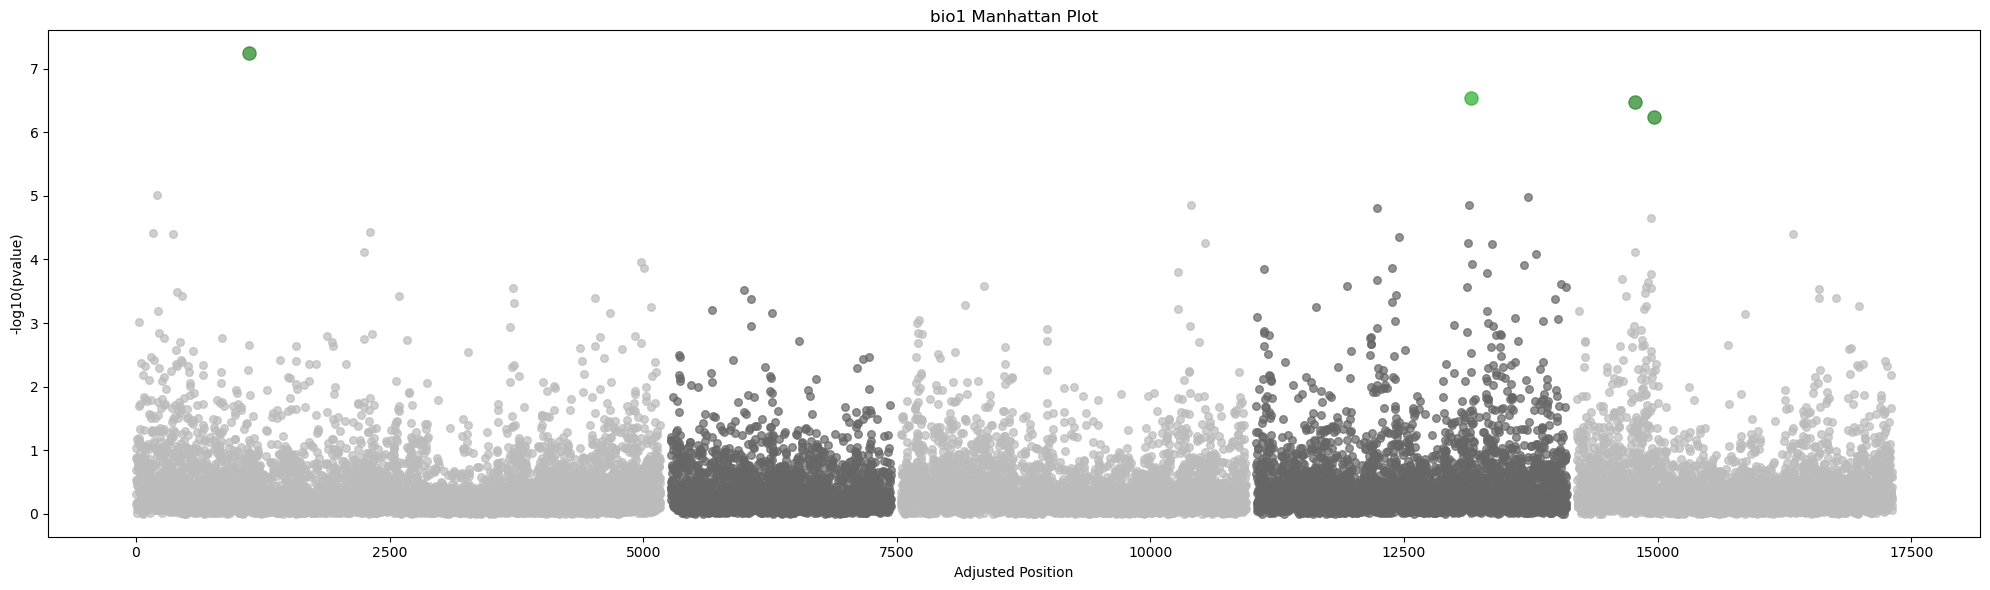

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Significance threshold
threshold_value = 0.05 / len(wza_lfmm)
threshold = -np.log10(threshold_value)
biovar = 'bio1'

# Create chrom_pos in wza_lfmm by combining 'chrom' and 'pos'
binomial_reg['chrom_pos'] = binomial_reg['chrom'].astype(str) + '_' + binomial_reg['pos'].astype(str)

# Copy the relevant columns for plotting
df = binomial_reg[['Z_pVal', 'pos', 'chrom', 'chrom_pos']].copy()

# Parse chromosome number and position
df['chromosome'] = df['chrom']
df['position'] = df['pos']
df['-log10(pvalue)'] = -np.log10(df['Z_pVal'])

# Define grey tones for each chromosome (alternating dark and light greys)
greyscale_colors = ['#666666', '#BBBBBB', '#666666', '#BBBBBB', '#666666', '#BBBBBB']

# Define green tones for significant points (alternating dark and light greens)
green_colors = ['#2aad2a', '#208420'] # '#006400', '#32CD32', '#006400', '#32CD32']  # Dark and light greens

# Calculate chromosome offsets to prevent overlap
chromosome_offsets = {}
offset = 0
for chrom in sorted(df['chromosome'].unique()):
    chromosome_offsets[chrom] = offset
    max_position = df[df['chromosome'] == chrom]['position'].max()
    offset += max_position + 100  # Add buffer to prevent overlap

# Apply offsets to the position
df['adjusted_position'] = df.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)

# Create the Manhattan plot
plt.figure(figsize=(20, 6))

# Plot each chromosome separately
for chrom in sorted(df['chromosome'].unique()):
    subset = df[df['chromosome'] == chrom]
    
    # Separate significant points (above threshold) and non-significant points
    significant = subset[subset['-log10(pvalue)'] >= threshold]
    non_significant = subset[subset['-log10(pvalue)'] < threshold]
    
    # Plot non-significant points in greyscale
    plt.scatter(
        non_significant['adjusted_position'],
        non_significant['-log10(pvalue)'],
        alpha=0.7, 
        c=greyscale_colors[chrom % len(greyscale_colors)],  # Apply greyscale color shades
        s=30,  # Default size for non-significant points
        label=f'Chr {chrom}'
    )
    
    # Plot significant points in alternating shades of green with bigger size
    plt.scatter(
        significant['adjusted_position'],
        significant['-log10(pvalue)'],
        alpha=0.7, 
        c=green_colors[chrom % len(green_colors)],  # Alternate green color shades
        s=90,  # Bigger size for significant points
        label=f'Significant Chr {chrom}'
    )

# Aesthetics
plt.xlabel('Adjusted Position')
plt.ylabel('-log10(pvalue)')
plt.title(f'{biovar} Manhattan Plot')

# Remove grid lines
plt.grid(False)

# Tight layout for better spacing
plt.tight_layout()
#plt.savefig("manhattan_plot_lfmm_zwa.svg", format="svg")
# Show the plot
plt.show()


In [24]:
## all samples wza on kendalltau
wza_kendall = pd.read_csv('../wza/wza_kendalltau_results_bio1_poly7.csv')

In [28]:
wza_kendall

,gene,SNPs,hits,Z,top_candidate_p,Z_pVal,chrom,pos
0,1_0,198,0,-5.382798,1.0,0.798578,1,0
1,1_1,3,0,-1.266673,1.0,0.806488,1,1
2,1_10,22,0,-1.211412,1.0,0.673413,1,10
3,1_100,53,0,3.029274,1.0,0.178330,1,100
4,1_1000,9,0,2.030071,1.0,0.103565,1,1000
...,...,...,...,...,...,...,...,...
16651,5_995,39,0,-4.429697,1.0,0.915933,5,995
16652,5_996,3,0,-0.225149,1.0,0.543046,5,996
16653,5_997,27,0,-2.670487,1.0,0.834929,5,997
16654,5_998,7,0,-2.067785,1.0,0.892356,5,998


In [26]:
wza_kendall['chrom'] = wza_kendall['gene'].str.split('_').str[0].astype(int)
wza_kendall['pos'] = wza_kendall['gene'].str.split('_').str[1].astype(int)

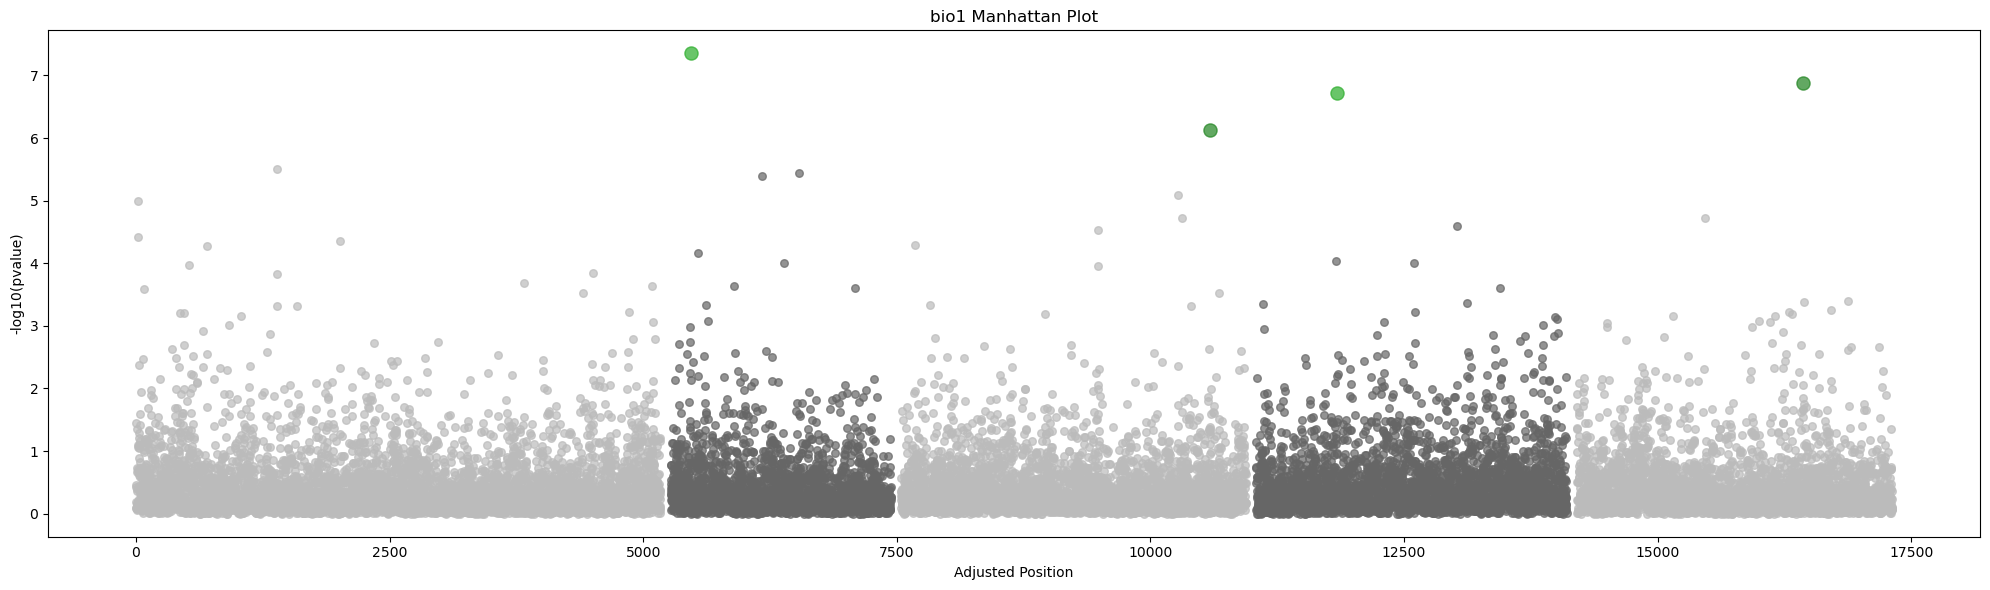

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Significance threshold
threshold_value = 0.05 / len(wza_kendall)
threshold = -np.log10(threshold_value)
biovar = 'bio1'

# Create chrom_pos in wza_lfmm by combining 'chrom' and 'pos'
wza_kendall['chrom_pos'] = wza_kendall['chrom'].astype(str) + '_' + wza_kendall['pos'].astype(str)

# Copy the relevant columns for plotting
df = wza_kendall[['Z_pVal', 'pos', 'chrom', 'chrom_pos']].copy()

# Parse chromosome number and position
df['chromosome'] = df['chrom']
df['position'] = df['pos']
df['-log10(pvalue)'] = -np.log10(df['Z_pVal'])

# Define grey tones for each chromosome (alternating dark and light greys)
greyscale_colors = ['#666666', '#BBBBBB', '#666666', '#BBBBBB', '#666666', '#BBBBBB']

# Define green tones for significant points (alternating dark and light greens)
green_colors = ['#2aad2a', '#208420'] # '#006400', '#32CD32', '#006400', '#32CD32']  # Dark and light greens

# Calculate chromosome offsets to prevent overlap
chromosome_offsets = {}
offset = 0
for chrom in sorted(df['chromosome'].unique()):
    chromosome_offsets[chrom] = offset
    max_position = df[df['chromosome'] == chrom]['position'].max()
    offset += max_position + 100  # Add buffer to prevent overlap

# Apply offsets to the position
df['adjusted_position'] = df.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)

# Create the Manhattan plot
plt.figure(figsize=(20, 6))

# Plot each chromosome separately
for chrom in sorted(df['chromosome'].unique()):
    subset = df[df['chromosome'] == chrom]
    
    # Separate significant points (above threshold) and non-significant points
    significant = subset[subset['-log10(pvalue)'] >= threshold]
    non_significant = subset[subset['-log10(pvalue)'] < threshold]
    
    # Plot non-significant points in greyscale
    plt.scatter(
        non_significant['adjusted_position'],
        non_significant['-log10(pvalue)'],
        alpha=0.7, 
        c=greyscale_colors[chrom % len(greyscale_colors)],  # Apply greyscale color shades
        s=30,  # Default size for non-significant points
        label=f'Chr {chrom}'
    )
    
    # Plot significant points in alternating shades of green with bigger size
    plt.scatter(
        significant['adjusted_position'],
        significant['-log10(pvalue)'],
        alpha=0.7, 
        c=green_colors[chrom % len(green_colors)],  # Alternate green color shades
        s=90,  # Bigger size for significant points
        label=f'Significant Chr {chrom}'
    )

# Aesthetics
plt.xlabel('Adjusted Position')
plt.ylabel('-log10(pvalue)')
plt.title(f'{biovar} Manhattan Plot')

# Remove grid lines
plt.grid(False)

# Tight layout for better spacing
plt.tight_layout()
#plt.savefig("manhattan_plot_lfmm_zwa.svg", format="svg")
# Show the plot
plt.show()


In [ ]:
annot = pd.read_csv('../signficant_intersection/genes_info_bonferronicor_tair10.csv')

/tmp/ipykernel_4062620/1497640755.py:37: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


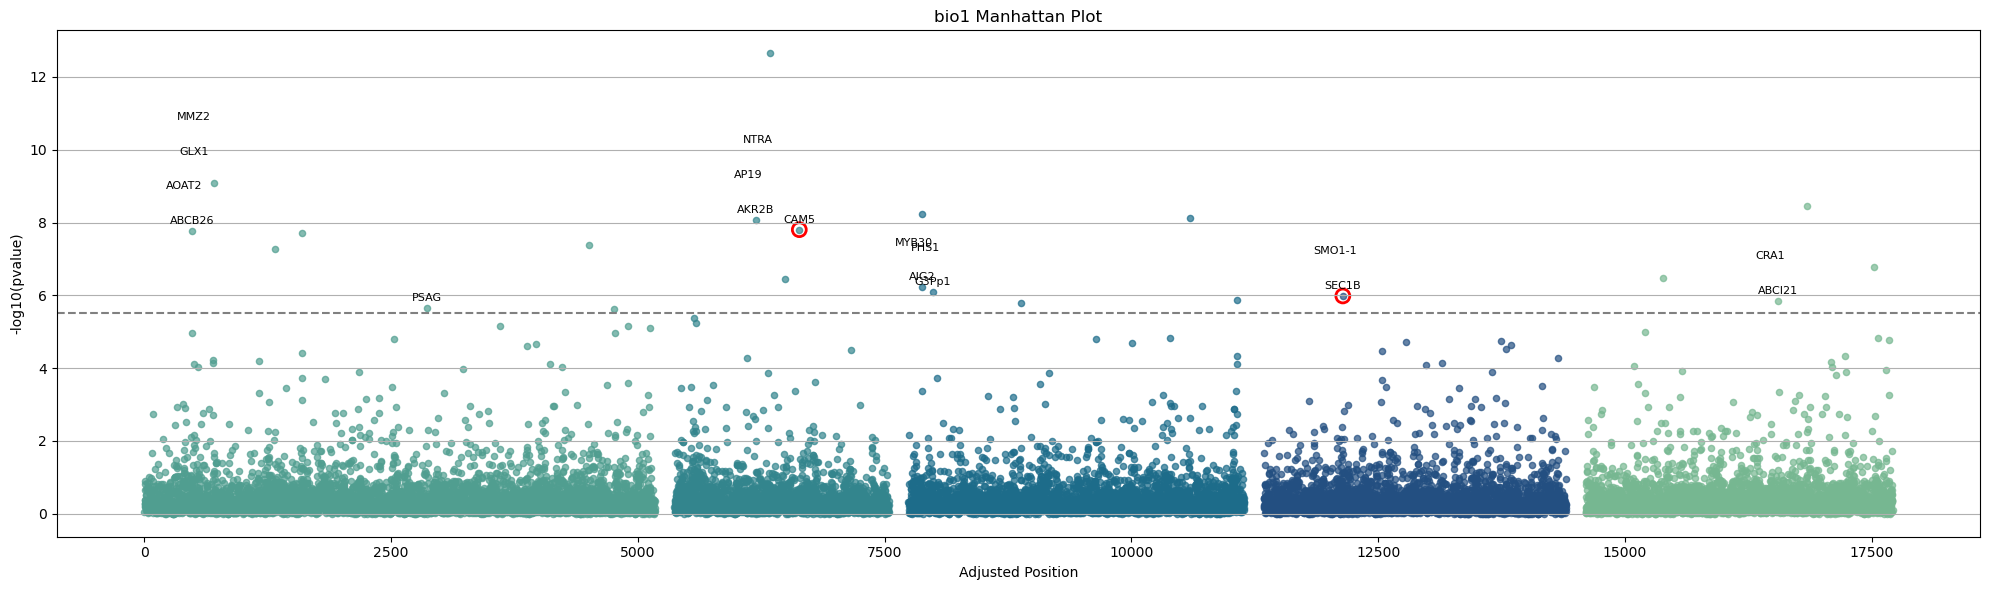

In [40]:
# Significance threshold
threshold_value = 0.05 / len(wza_lfmm)
threshold = -np.log10(threshold_value)
biovar = 'bio1'

# Create chrom_pos in wza_lfmm by combining 'chrom' and 'pos'
wza_lfmm['chrom_pos'] = wza_lfmm['chrom'].astype(str) + '_' + wza_lfmm['pos'].astype(str)

# Copy the relevant columns for plotting
df = wza_lfmm[['Z_pVal', 'pos', 'chrom', 'chrom_pos']].copy()

# Parse chromosome number and position
df['chromosome'] = df['chrom']
df['position'] = df['pos']
df['-log10(pvalue)'] = -np.log10(df['Z_pVal'])

# Define colors for each chromosome
colors = sns.color_palette("crest", n_colors=5)

# Calculate chromosome offsets to prevent overlap
chromosome_offsets = {}
offset = 0
for chrom in sorted(df['chromosome'].unique()):
    chromosome_offsets[chrom] = offset
    max_position = df[df['chromosome'] == chrom]['position'].max()
    offset += max_position + 200  # Add buffer to prevent overlap

# Apply offsets to the position
df['adjusted_position'] = df.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)

# Create the Manhattan plot
plt.figure(figsize=(20, 6))

# Plot each chromosome separately
for chrom in sorted(df['chromosome'].unique()):
    subset = df[df['chromosome'] == chrom]
    plt.scatter(
        subset['adjusted_position'],
        subset['-log10(pvalue)'],
        alpha=0.7, 
        c=colors[chrom % len(colors)], 
        label=f'Chr {chrom}',
        s=20
    )

# Aesthetics
plt.xlabel('Adjusted Position')
plt.ylabel('-log10(pvalue)')
plt.title(f'{biovar} Manhattan Plot')
plt.grid(axis='y')

# Add a threshold line for significance
plt.axhline(y=threshold, color='grey', linestyle='dashed')

# Identify significant blocks in wza_lfmm
significant_blocks = df[df['-log10(pvalue)'] >= threshold]

# Merge significant blocks with the annotation dataframe based on chrom_pos and block
annotated_blocks = significant_blocks.merge(annot, left_on='chrom_pos', right_on='block', how='inner')

# Annotate the significant points with 'gene_name' and space annotations vertically
# Annotate the significant points with 'gene_name' and space annotations both horizontally and vertically
for chrom_pos, group in annotated_blocks.groupby('block'):
    # Sort the group by gene_name to ensure consistent ordering
    group = group.sort_values(by='gene_name')
    
    # Set initial offsets for annotations
    vertical_offset = 0  
    horizontal_offset = 0
    previous_position = None  # Track the previous annotation position
    
    for i, row in group.iterrows():
        current_position = row['adjusted_position']
        
        # Adjust vertical and horizontal offsets if positions are too close
        if previous_position is not None and abs(current_position - previous_position) < 50:
            vertical_offset += 25  # Increase vertical offset for close annotations
            horizontal_offset = (-80 if horizontal_offset == 0 else 20)  # Alternate horizontal offset left/right
        else:
            vertical_offset = 0  # Reset vertical offset if there's enough distance
            horizontal_offset = 0  # Reset horizontal offset
        
        # Annotate the plot with gene name, applying both vertical and horizontal adjustments
        plt.annotate(
            row['gene_name'], 
            (row['adjusted_position'] + horizontal_offset, row['-log10(pvalue)']),
            textcoords="offset points",  # Specify the offset point for the text
            xytext=(0, 5 + vertical_offset),  # Increment vertical offset for each annotation
            ha='center',    # Align horizontally to center
            fontsize=8,
            color='black'
        )
        
        # Update previous position for the next comparison
        previous_position = current_position

# Highlight specific genes if needed
genes = ['2_1265', '4_801']  # List of specific genes to highlight
for gene in genes:
    chrom, pos = map(int, gene.split('_'))
    subset_gene = df[(df['chromosome'] == chrom) & (df['position'] == pos)]
    if not subset_gene.empty:
        plt.scatter(
            subset_gene['adjusted_position'],
            subset_gene['-log10(pvalue)'],
            edgecolor='red',
            linewidth=2,
            facecolor='none',
            s=100,
            label=f'Gene {gene}'
        )

plt.tight_layout()
plt.show()


In [ ]:
2_970	AT2G22540	SVP	Encodes a nuclear protein that acts as a floral repressor and that functions within the thermosensory pathway. SVP represses FT expression via direct binding to the vCArG III motif in the FT promoter.
2_970	AT2G22630	AGL17	Encodes a MADs domain containing protein involved in promoting flowering. Loss of function mutations show delayed flowering in long days and reduced levels of LFY and AP1 expression.
2_970	AT2G22570	NIC 1.00	encodes a nicotinamidase that converts nicotinamide into nicotinic acid. As such the encoded enzyme is involved in the pyridine nucleotide salvage pathway which may be connected to the de novo NAD biosynthesis through the ABA signaling pathway.

In [42]:
annot = pd.read_csv('../signficant_intersection/df_lfmm_wza_block_gene_info_ncbi.csv')

/tmp/ipykernel_4062620/985357838.py:37: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


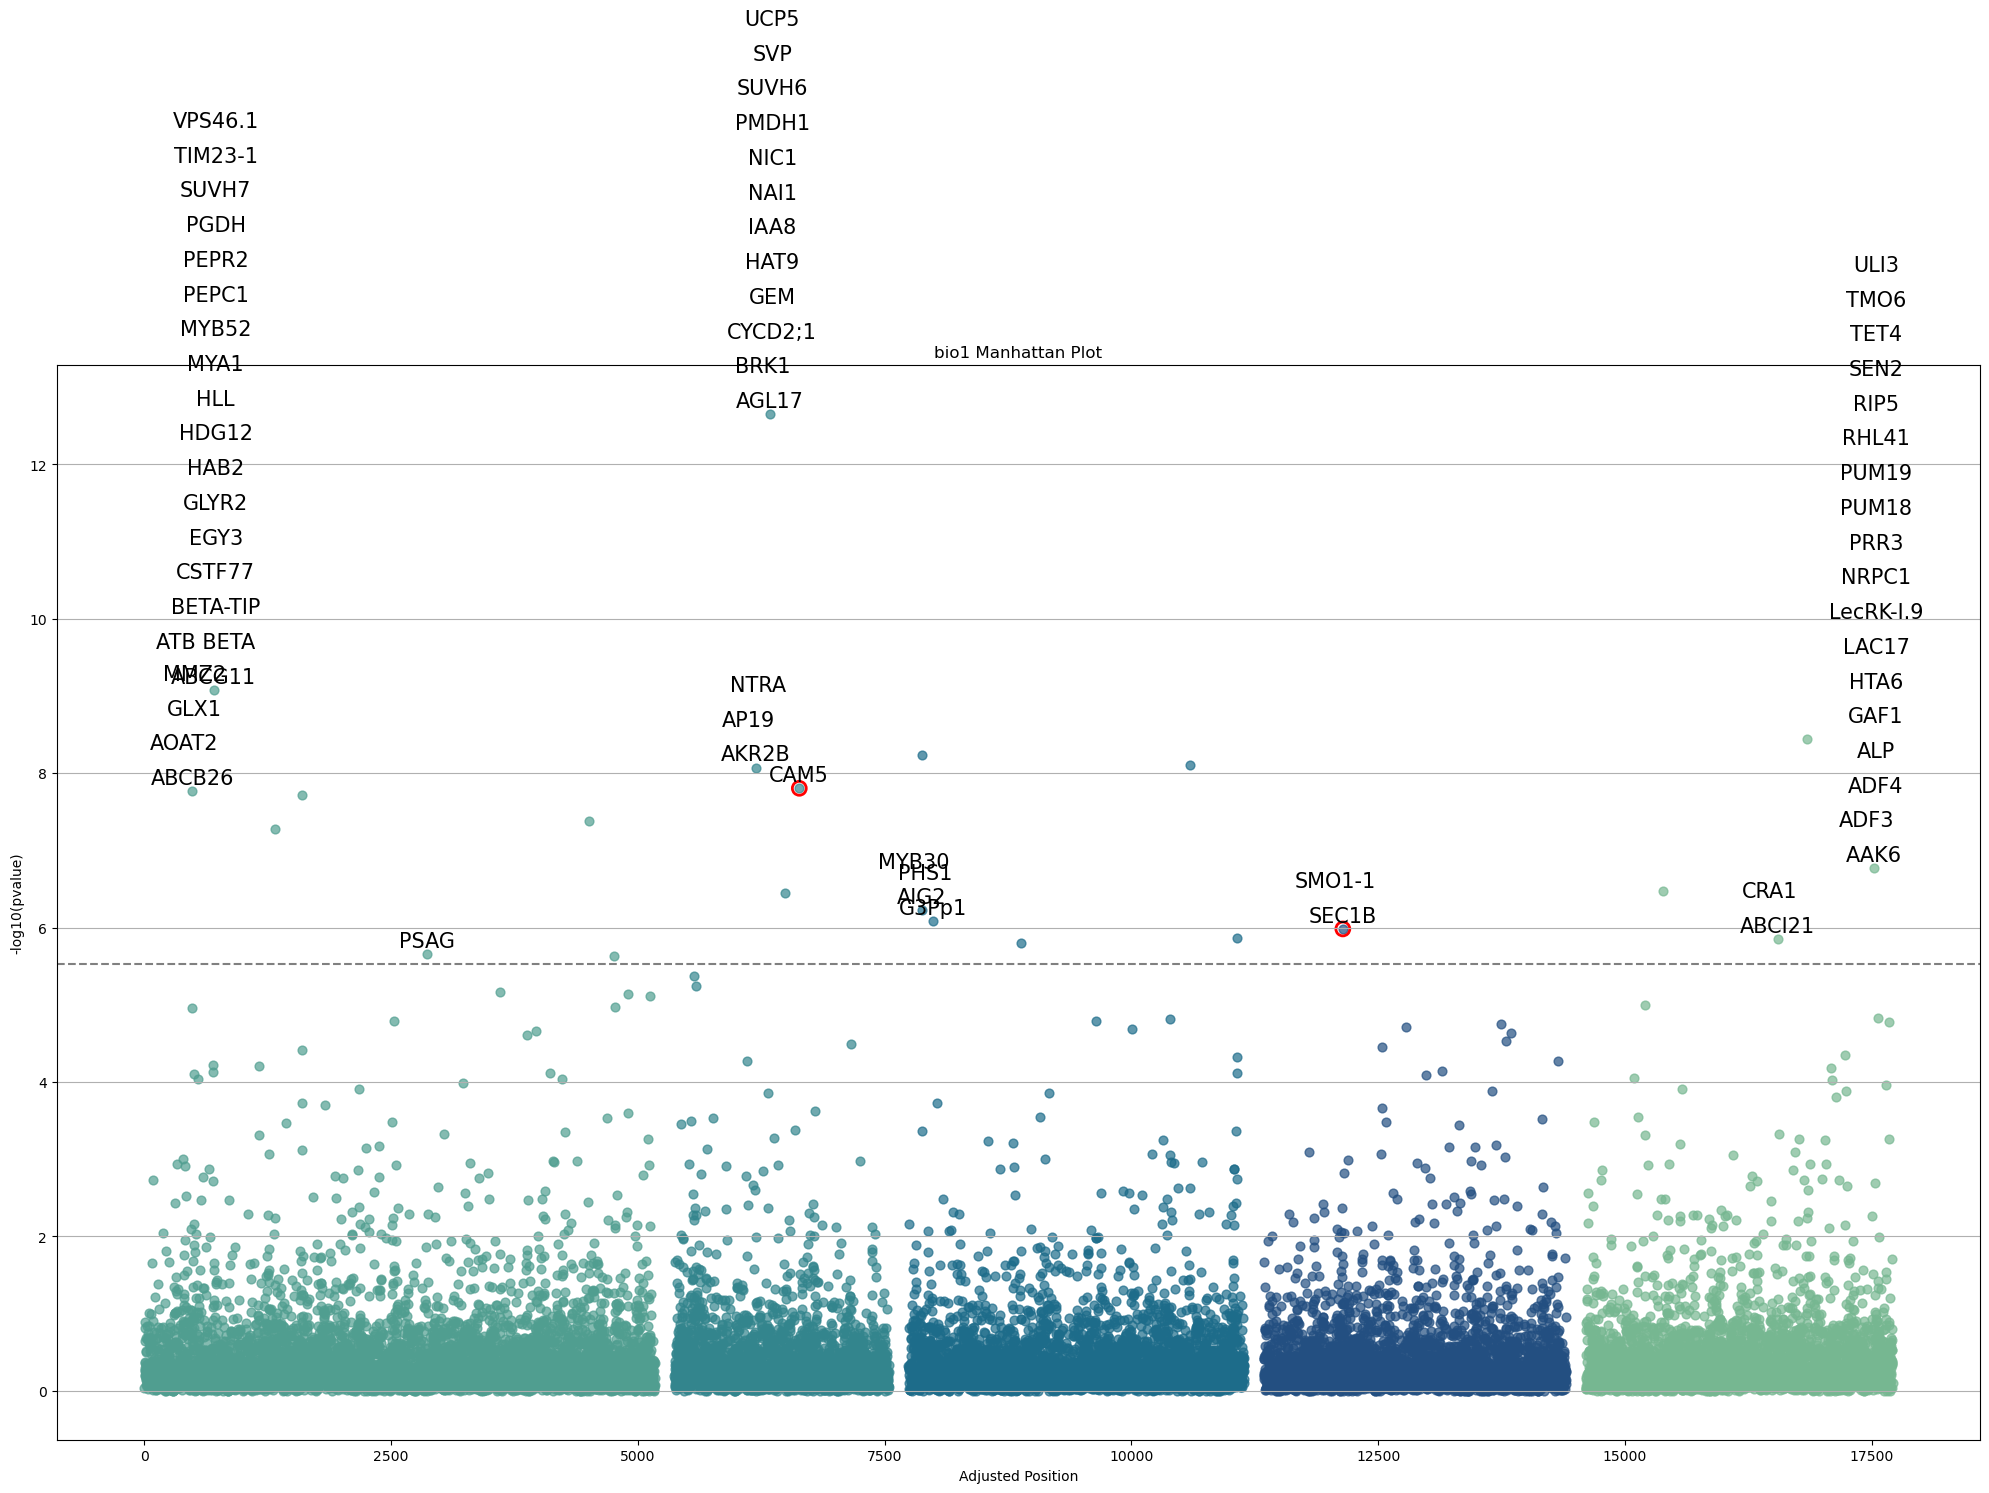

In [72]:
# Significance threshold
threshold_value = 0.05 / len(wza_lfmm)
threshold = -np.log10(threshold_value)
biovar = 'bio1'

# Create chrom_pos in wza_lfmm by combining 'chrom' and 'pos'
wza_lfmm['chrom_pos'] = wza_lfmm['chrom'].astype(str) + '_' + wza_lfmm['pos'].astype(str)

# Copy the relevant columns for plotting
df = wza_lfmm[['Z_pVal', 'pos', 'chrom', 'chrom_pos']].copy()

# Parse chromosome number and position
df['chromosome'] = df['chrom']
df['position'] = df['pos']
df['-log10(pvalue)'] = -np.log10(df['Z_pVal'])

# Define colors for each chromosome
colors = sns.color_palette("crest", n_colors=5)

# Calculate chromosome offsets to prevent overlap
chromosome_offsets = {}
offset = 0
for chrom in sorted(df['chromosome'].unique()):
    chromosome_offsets[chrom] = offset
    max_position = df[df['chromosome'] == chrom]['position'].max()
    offset += max_position + 200  # Add buffer to prevent overlap

# Apply offsets to the position
df['adjusted_position'] = df.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)

# Create the Manhattan plot
plt.figure(figsize=(20, 15))

# Plot each chromosome separately
for chrom in sorted(df['chromosome'].unique()):
    subset = df[df['chromosome'] == chrom]
    plt.scatter(
        subset['adjusted_position'],
        subset['-log10(pvalue)'],
        alpha=0.7, 
        c=colors[chrom % len(colors)], 
        label=f'Chr {chrom}',
        s=40
    )

# Aesthetics
plt.xlabel('Adjusted Position')
plt.ylabel('-log10(pvalue)')
plt.title(f'{biovar} Manhattan Plot')
plt.grid(axis='y')

# Add a threshold line for significance
plt.axhline(y=threshold, color='grey', linestyle='dashed')

# Identify significant blocks in wza_lfmm
significant_blocks = df[df['-log10(pvalue)'] >= threshold]

# Merge significant blocks with the annotation dataframe based on chrom_pos and block
annotated_blocks = significant_blocks.merge(annot, left_on='chrom_pos', right_on='block', how='inner')

# Annotate the significant points with 'gene_name' and space annotations vertically
# Annotate the significant points with 'gene_name' and space annotations both horizontally and vertically
for chrom_pos, group in annotated_blocks.groupby('block'):
    # Sort the group by gene_name to ensure consistent ordering
    group = group.sort_values(by='gene_name')
    
    # Set initial offsets for annotations
    vertical_offset = 0  
    horizontal_offset = 0
    previous_position = None  # Track the previous annotation position
    
    for i, row in group.iterrows():
        current_position = row['adjusted_position']
        
        # Adjust vertical and horizontal offsets if positions are too close
        if previous_position is not None and abs(current_position - previous_position) < 50:
            vertical_offset += 25  # Increase vertical offset for close annotations
            horizontal_offset = (-80 if horizontal_offset == 0 else 20)  # Alternate horizontal offset left/right
        else:
            vertical_offset = 0  # Reset vertical offset if there's enough distance
            horizontal_offset = 0  # Reset horizontal offset
        
        # Annotate the plot with gene name, applying both vertical and horizontal adjustments
        plt.annotate(
            row['gene_name'], 
            (row['adjusted_position'] + horizontal_offset, row['-log10(pvalue)']),
            textcoords="offset points",  # Specify the offset point for the text
            xytext=(0, 5 + vertical_offset),  # Increment vertical offset for each annotation
            ha='center',    # Align horizontally to center
            fontsize=15,
            color='black',
            
        )
        
        # Update previous position for the next comparison
        previous_position = current_position

# Highlight specific genes if needed
genes = ['2_1265', '4_801']  # List of specific genes to highlight
for gene in genes:
    chrom, pos = map(int, gene.split('_'))
    subset_gene = df[(df['chromosome'] == chrom) & (df['position'] == pos)]
    if not subset_gene.empty:
        plt.scatter(
            subset_gene['adjusted_position'],
            subset_gene['-log10(pvalue)'],
            edgecolor='red',
            linewidth=2,
            facecolor='none',
            s=100,
            label=f'Gene {gene}'
        )

plt.tight_layout()
plt.show()
